# Homework 10 — Object Tracking

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]

## Step 1 — Select video, object and generate the template

Surveillance video from a store. Tracked object: a person in a green hoodie entering the store.

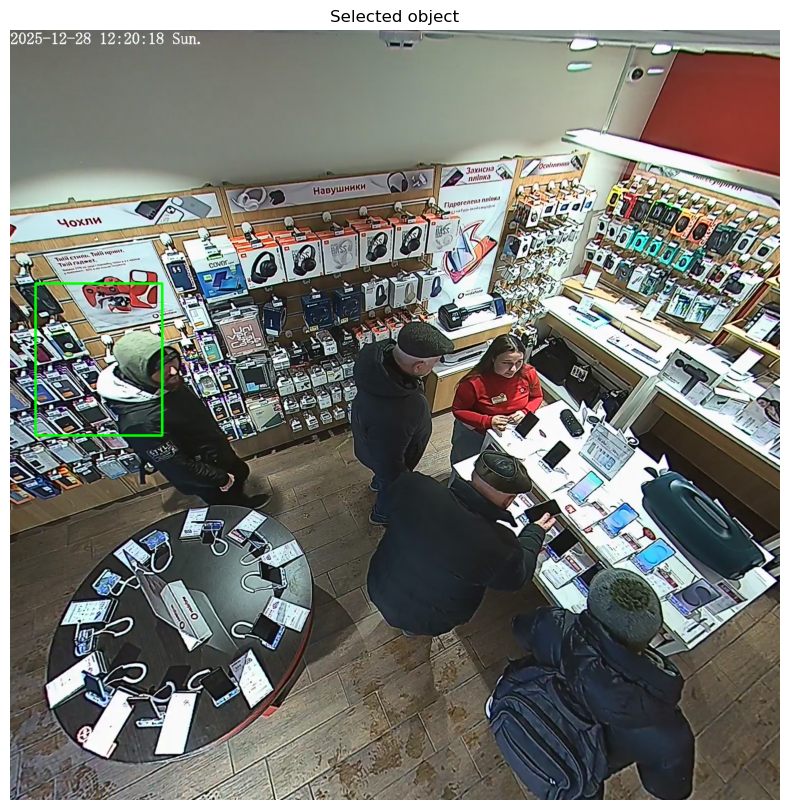

In [2]:
cap = cv2.VideoCapture('video2.mp4')

# Start from the frame where the person enters the store (~82s)
START_FRAME = 2050
cap.set(cv2.CAP_PROP_POS_FRAMES, START_FRAME)
ret, first_frame = cap.read()
cap.release()

# Bounding box around the person: (x, y, w, h)
bbox = (50, 500, 250, 300)

x, y, w, h = bbox
display = first_frame.copy()
cv2.rectangle(display, (x, y), (x + w, y + h), (0, 255, 0), 3)

plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
plt.title('Selected object')
plt.axis('off')
plt.show()

## Steps 2, 3, 4 — KCF tracker

In [3]:
tracker = cv2.TrackerKCF_create()

cap = cv2.VideoCapture('video2.mp4')
cap.set(cv2.CAP_PROP_POS_FRAMES, START_FRAME)
ret, frame = cap.read()
tracker.init(frame, bbox)

for i in range(15):
    ret, frame = cap.read()
    if not ret:
        break

    ok, new_bbox = tracker.update(frame)

    if ok:
        x, y, w, h = [int(v) for v in new_bbox]
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 3)
        print(f'Frame {i}: bbox = ({x}, {y}, {w}, {h})')
    else:
        print(f'Frame {i}: LOST')

    cv2.imwrite(f'kcf_frame_{i:02d}.jpg', frame)

cap.release()

Frame 0: bbox = (50, 500, 250, 300)
Frame 1: bbox = (52, 498, 250, 300)
Frame 2: bbox = (54, 496, 250, 300)
Frame 3: bbox = (60, 496, 250, 300)
Frame 4: bbox = (62, 494, 250, 300)
Frame 5: bbox = (66, 492, 250, 300)
Frame 6: bbox = (70, 492, 250, 300)
Frame 7: bbox = (74, 490, 250, 300)
Frame 8: bbox = (78, 490, 250, 300)
Frame 9: bbox = (82, 488, 250, 300)
Frame 10: bbox = (84, 488, 250, 300)
Frame 11: bbox = (86, 488, 250, 300)
Frame 12: bbox = (88, 488, 250, 300)
Frame 13: bbox = (88, 488, 250, 300)
Frame 14: bbox = (90, 488, 250, 300)


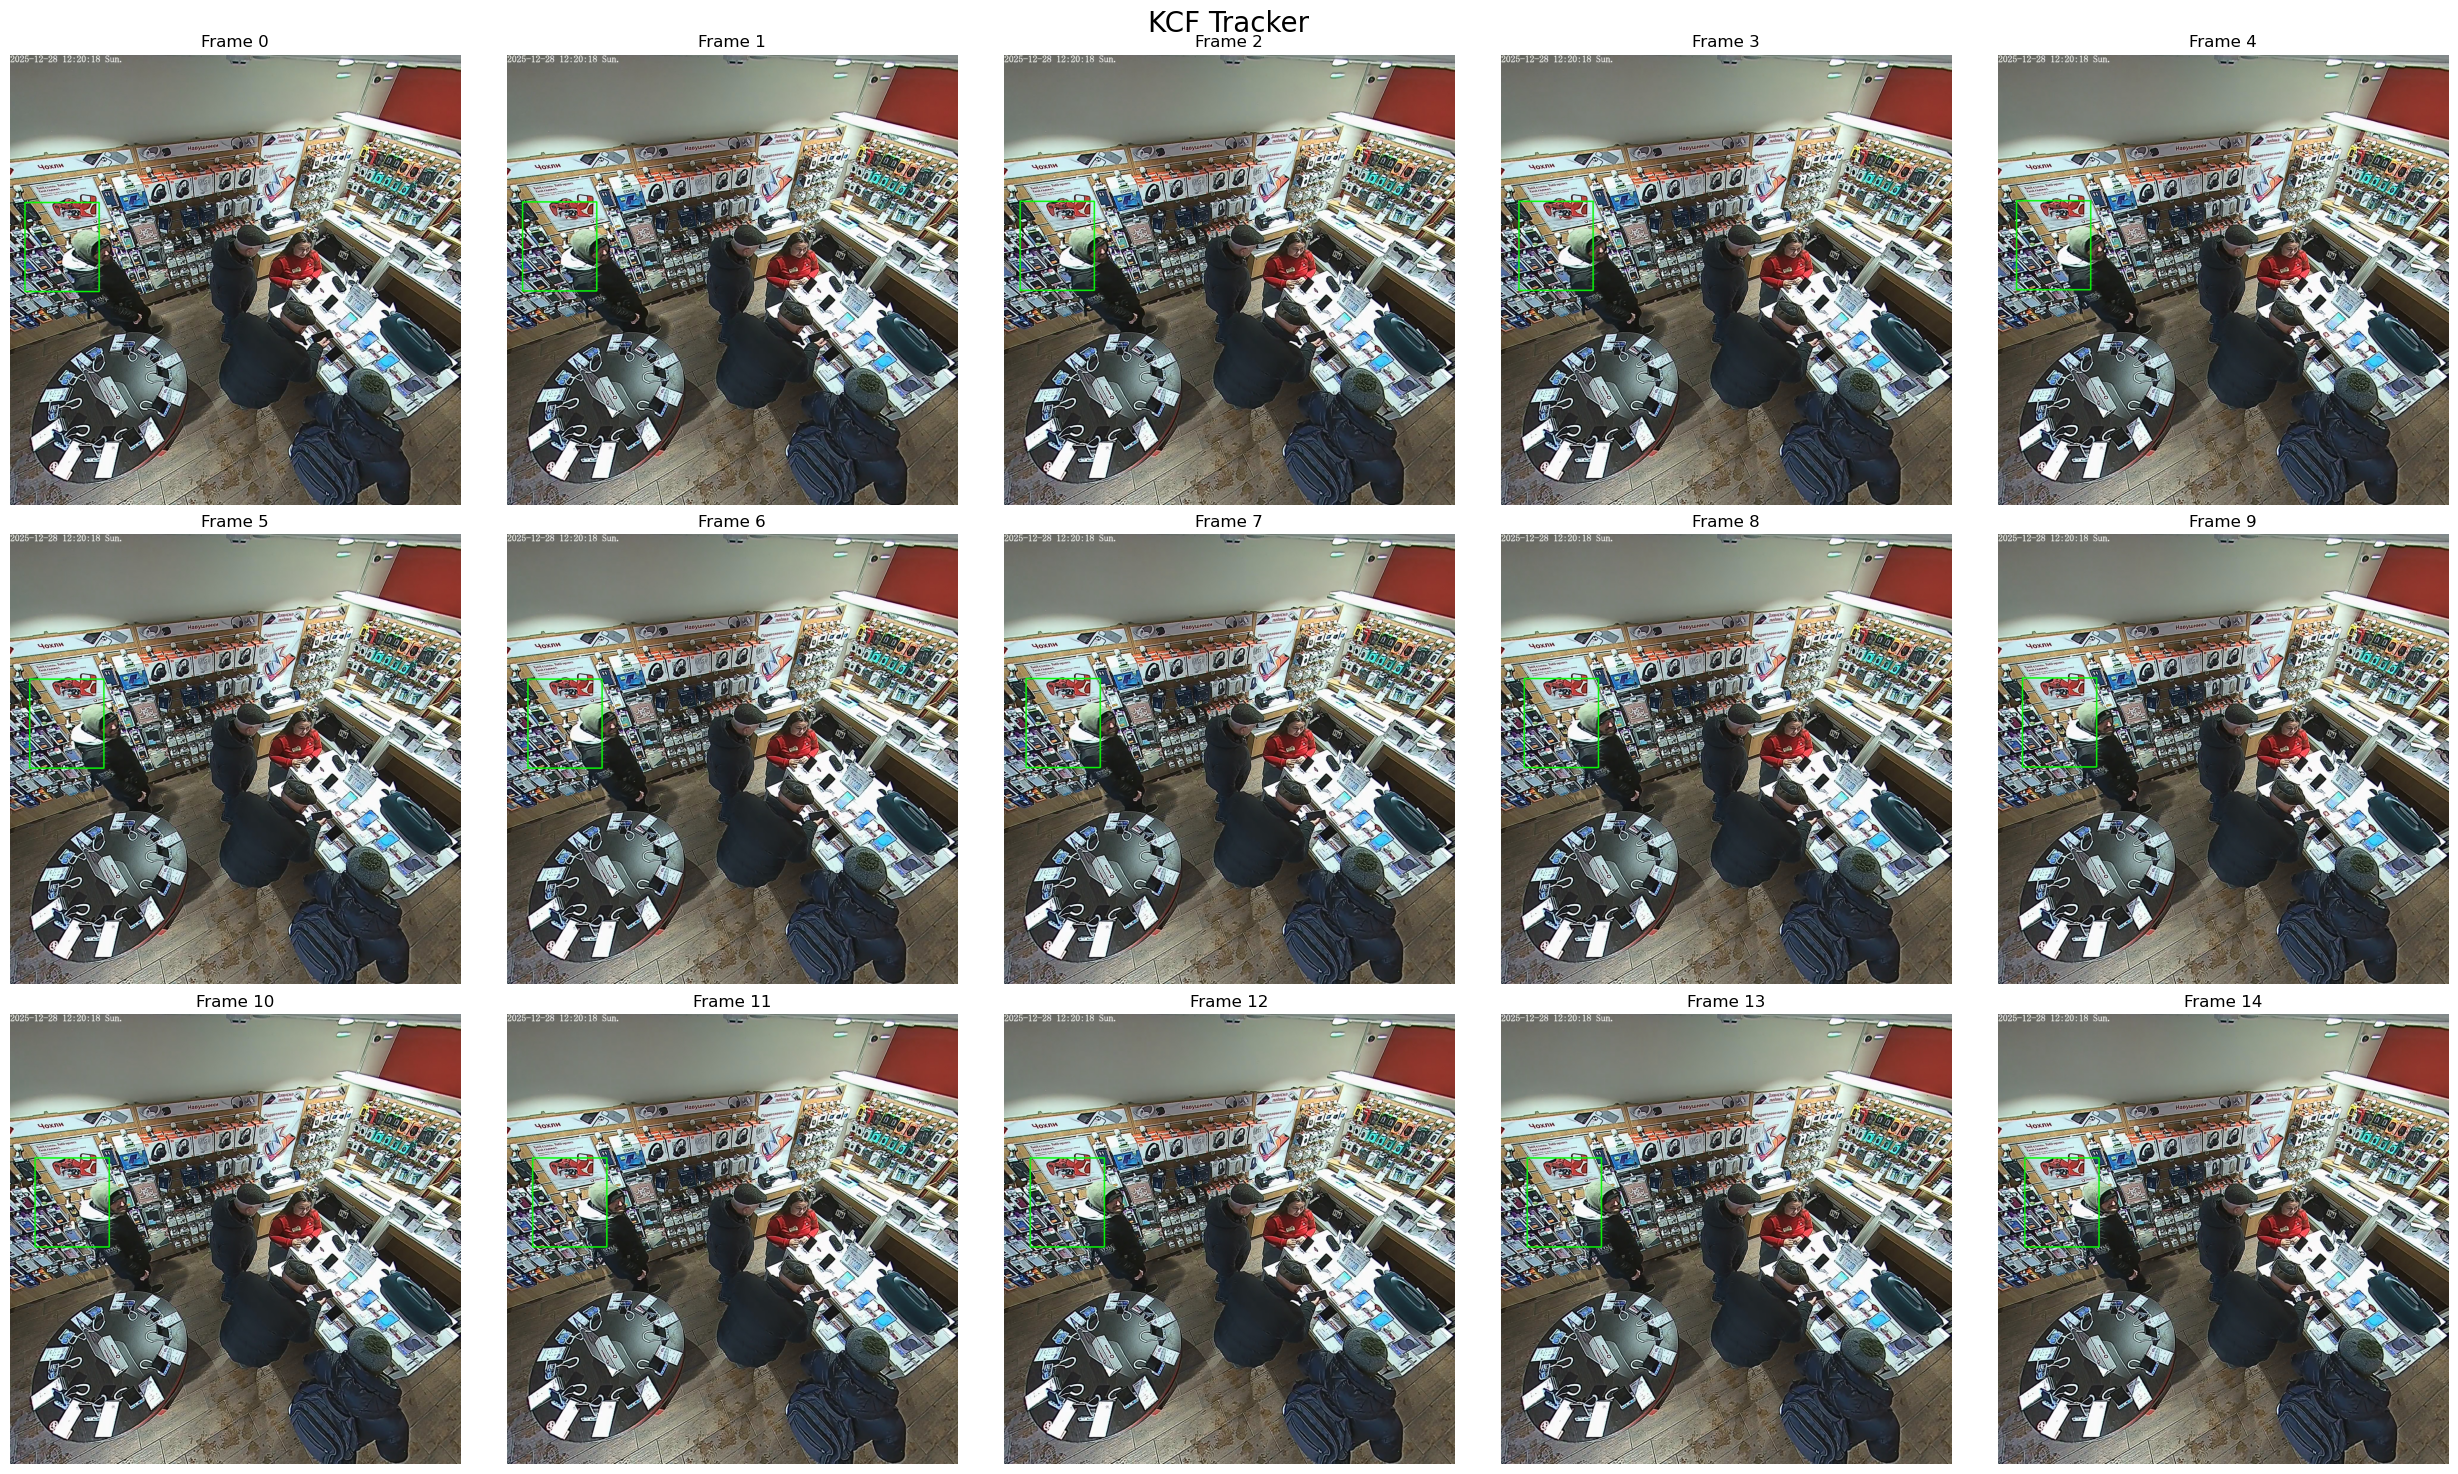

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(25, 15))
for i, ax in enumerate(axes.flat):
    img = cv2.imread(f'kcf_frame_{i:02d}.jpg')
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Frame {i}')
    ax.axis('off')
plt.suptitle('KCF Tracker', fontsize=20)
plt.tight_layout()
plt.show()

## Step 5 — CSRT tracker (repeat steps 2, 3, 4)

In [5]:
tracker = cv2.TrackerCSRT_create()

cap = cv2.VideoCapture('video2.mp4')
cap.set(cv2.CAP_PROP_POS_FRAMES, START_FRAME)
ret, frame = cap.read()
tracker.init(frame, bbox)

for i in range(15):
    ret, frame = cap.read()
    if not ret:
        break

    ok, new_bbox = tracker.update(frame)

    if ok:
        x, y, w, h = [int(v) for v in new_bbox]
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 3)
        print(f'Frame {i}: bbox = ({x}, {y}, {w}, {h})')
    else:
        print(f'Frame {i}: LOST')

    cv2.imwrite(f'csrt_frame_{i:02d}.jpg', frame)

cap.release()

Frame 0: bbox = (51, 499, 250, 300)
Frame 1: bbox = (45, 489, 265, 318)
Frame 2: bbox = (46, 487, 271, 325)
Frame 3: bbox = (50, 486, 271, 325)
Frame 4: bbox = (57, 489, 265, 318)
Frame 5: bbox = (57, 488, 265, 318)
Frame 6: bbox = (59, 486, 265, 318)
Frame 7: bbox = (54, 482, 271, 325)
Frame 8: bbox = (55, 486, 271, 325)
Frame 9: bbox = (56, 489, 271, 325)
Frame 10: bbox = (57, 496, 260, 312)
Frame 11: bbox = (52, 498, 260, 312)
Frame 12: bbox = (45, 495, 265, 318)
Frame 13: bbox = (42, 489, 276, 331)
Frame 14: bbox = (41, 486, 287, 345)


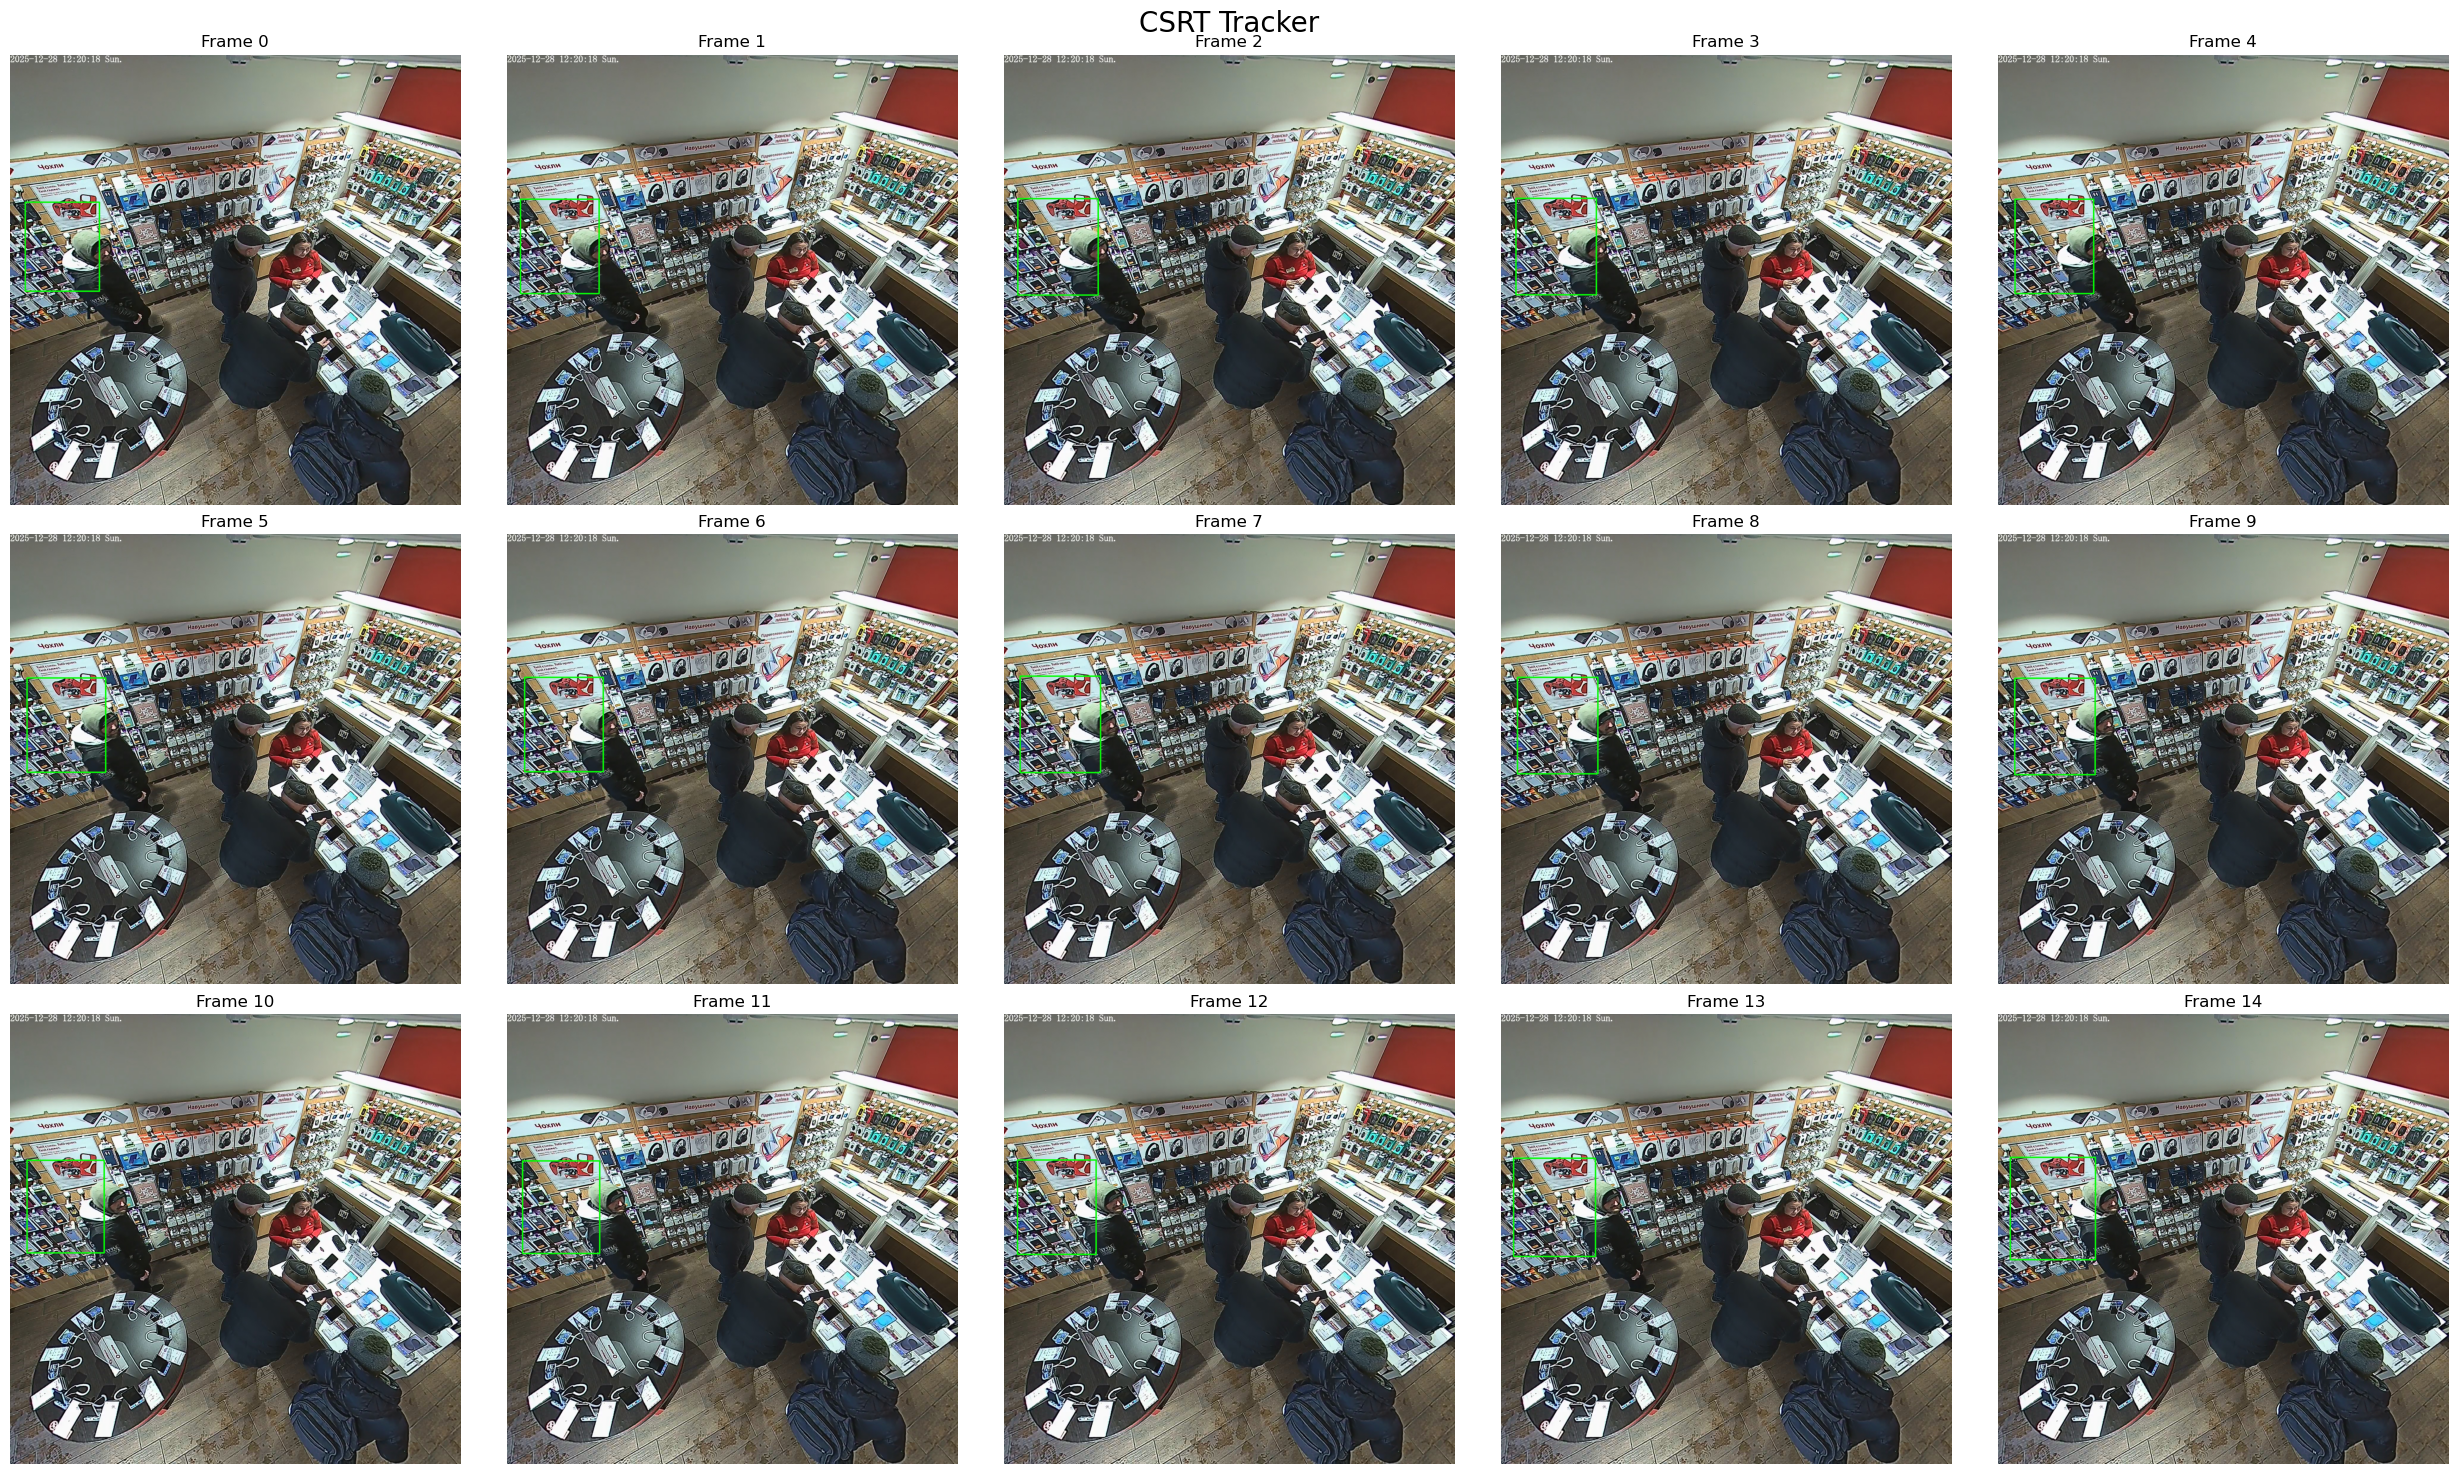

In [6]:
fig, axes = plt.subplots(3, 5, figsize=(25, 15))
for i, ax in enumerate(axes.flat):
    img = cv2.imread(f'csrt_frame_{i:02d}.jpg')
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Frame {i}')
    ax.axis('off')
plt.suptitle('CSRT Tracker', fontsize=20)
plt.tight_layout()
plt.show()

## Step 6 — Compare the results

**Do you see any differences? If so, what are they?**

- KCF сохраняет фиксированный размер рамки (250x300) на протяжении всего трекинга, меняется только позиция.
- CSRT адаптирует размер рамки (до 287x345), подстраиваясь под объект по мере его движения.
- Траектории немного отличаются - CSRT иначе реагирует на перемещение объекта.

**Does one tracker perform better than the other? In what way?**

- **CSRT** точнее: он подстраивает масштаб рамки и использует карту пространственной надёжности, чтобы лучше отделять объект от фона.
- **KCF** быстрее, но не адаптирует масштаб. Может потерять объект, если его видимый размер сильно изменится.
- На этом видео оба трекера успешно следят за человеком, но CSRT плотнее облегает цель.